#  CNN Emotion Classification
**Architecture:** 1D Convolutional Neural Network (CNN)  
**Task:** 6-class tweet emotion detection  
**Dataset:** Kaggle Emotion Dataset  
---
### Pipeline Overview
```
Raw CSV → EDA → Clean → Stopword Filter → Stem → Tokenize → Pad → CNN → Evaluate
```

##  1. Imports

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
# ── Reproducibility 
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(" All imports ready.")

 All imports ready.


##  2. Load Dataset

In [ ]:
# Uncomment to upload in Colab:
# from google.colab import files
# files.upload()
df = pd.read_csv('emotion_dataset_raw.csv')
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
df.head()

Shape   : (22176, 2)
Columns : ['Emotion', 'Text']


,Emotion,Text
0,neutral,Why ?
1,joy,Sage Act upgrade on my to do list for tommorow.
2,sadness,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3,joy,Such an eye ! The true hazel eye-and so brill...
4,joy,@Iluvmiasantos ugh babe.. hugggzzz for u .! b...


##  3. Exploratory Data Analysis

In [ ]:
print(f"Null values:\n{df.isnull().sum()}")
print(f"\nLabel distribution:\n{df['Emotion'].value_counts()}")

Null values:
Emotion    0
Text       0
dtype: int64
Label distribution:
Emotion
joy         7044
sadness     4231
fear        3450
anger       2761
surprise    2587
neutral     1439
disgust      569
shame         95
Name: count, dtype: int64


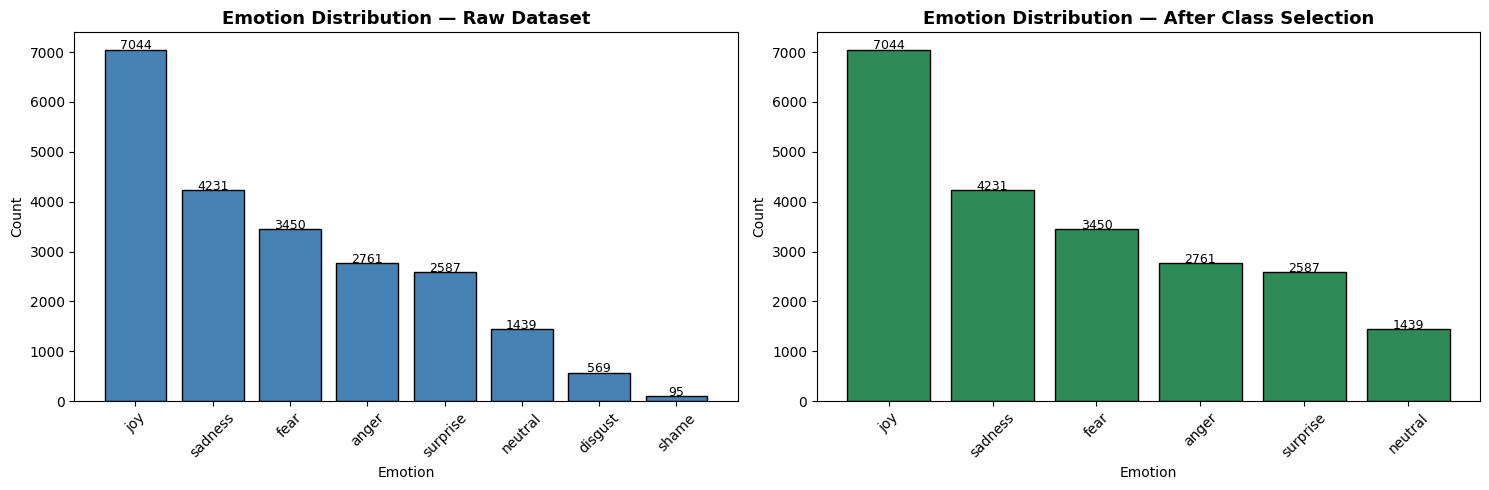

Dataset size after filtering: (21512, 2)


In [ ]:
# Keep only the 6 target emotion classes
TARGET_CLASSES = ['joy', 'sadness', 'fear', 'anger', 'surprise', 'neutral']
data = df[df['Emotion'].isin(TARGET_CLASSES)].copy().reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Before
counts_before = df['Emotion'].value_counts()
axes[0].bar(counts_before.index, counts_before.values, color='steelblue', edgecolor='black')
axes[0].set_title('Emotion Distribution — Raw Dataset', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=9)
# After
counts_after = data['Emotion'].value_counts()
axes[1].bar(counts_after.index, counts_after.values, color='seagreen', edgecolor='black')
axes[1].set_title('Emotion Distribution — After Class Selection', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts_after.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('eda_emotion_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Dataset size after filtering: {data.shape}")

##  4. Text Preprocessing
Three-stage pipeline applied in order:
1. **Clean** — remove URLs, mentions, numbers, punctuation
2. **Stopword removal** — drop common stopwords but **preserve** negations, intensifiers, and emotion-relevant words
3. **Stemming** — reduce words to their root form (Porter Stemmer)

In [ ]:
# ── Stage 1: Clean 
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)             # remove @mentions
    text = re.sub(r'\d+', '', text)              # remove numbers
    text = re.sub(r'[^\w\s]', '', text)          # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()     # collapse whitespace
    return text
# ── Stage 2: Stopword removal (emotion-aware) 
KEEP_WORDS = {
    # Negations
    "not", "no", "never", "none", "nobody", "nothing", "neither", "nor",
    "cannot", "without", "lack",
    # Intensifiers
    "very", "too", "so", "extremely", "highly", "really", "absolutely",
    "completely", "totally", "utterly", "deeply", "strongly", "incredibly",
    "super", "quite", "rather", "especially",
    # Downtoners
    "slightly", "somewhat", "barely", "hardly", "scarcely", "less", "least",
    # Contrast
    "but", "however", "though", "although", "yet", "still",
    # Emotional state verbs
    "feel", "feels", "felt", "feeling", "seem", "seems",
    # Certainty
    "maybe", "perhaps", "probably", "definitely", "certainly",
    # Focus
    "just", "even", "only", "almost"
}
raw_stopwords = set(stopwords.words('english'))
filtered_stopwords = raw_stopwords - KEEP_WORDS
def remove_stopwords(text):
    return ' '.join([t for t in text.split() if t not in filtered_stopwords])
# ── Stage 3: Stemming 
stemmer = PorterStemmer()
def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])
# ── Quick sanity check 
example = 'I am NOT happy today!! Check http://example.com @user123'
step1 = clean_text(example)
step2 = remove_stopwords(step1)
step3 = stem_text(step2)
print(f"Original : {example}")
print(f"Cleaned  : {step1}")
print(f"Stopwords: {step2}")
print(f"Stemmed  : {step3}")

Original : I am NOT happy today!! Check http://example.com @user123
Cleaned  : i am not happy today check
Stopwords: not happy today check
Stemmed  : not happi today check


In [ ]:
# ── Apply full pipeline 
data['Text'] = data['Text'].apply(clean_text)
data['Text'] = data['Text'].apply(remove_stopwords)
data['Text'] = data['Text'].apply(stem_text)
# ── Drop empty / degenerate rows 
before = len(data)
data = data.dropna(subset=['Text', 'Emotion'])
data = data[data['Text'].str.strip() != ''].reset_index(drop=True)
data = data[data['Emotion'].str.strip() != ''].reset_index(drop=True)
print(f"Removed {before - len(data)} degenerate rows.")
print(f"Clean dataset size: {data.shape}")
data[['Text', 'Emotion']].head()

Removed 189 degenerate rows.
Clean dataset size: (21323, 2)


,Text,Emotion
0,sage act upgrad list tommorow,joy
1,way homegirl babi funer man hate funer realli ...,sadness
2,eye true hazel eyeand so brilliant regular fea...,joy
3,ugh babe hugggzzz u babe naamaz nga ako e babe...,joy
4,im expect extrem import phonecal minut terror ...,fear


## ️ 5. Label Encoding & Train / Val / Test Split

In [ ]:
X = data['Text']
y = data['Emotion']
# 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)
print(f"Train : {len(X_train):>6} samples")
print(f"Val   : {len(X_val):>6} samples")
print(f"Test  : {len(X_test):>6} samples")

Train :  14926 samples
Val   :   3198 samples
Test  :   3199 samples


In [ ]:
NUM_CLASSES = 6
le = LabelEncoder()
y_train_enc = to_categorical(le.fit_transform(y_train), num_classes=NUM_CLASSES)
y_val_enc   = to_categorical(le.transform(y_val),   num_classes=NUM_CLASSES)
y_test_enc  = to_categorical(le.transform(y_test),  num_classes=NUM_CLASSES)
print("Label mapping:")
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {idx} → {cls}")
print(f"\ny_train shape: {y_train_enc.shape}")

Label mapping:
  0 → anger
  1 → fear
  2 → joy
  3 → neutral
  4 → sadness
  5 → surprise
y_train shape: (14926, 6)


##  6. Tokenization & Sequence Padding

In [ ]:
MAX_WORDS = 10000  # vocabulary size
MAX_LEN   = 100    # max sequence length
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
def encode(texts):
    return pad_sequences(
        tokenizer.texts_to_sequences(texts),
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )
X_train_enc = encode(X_train)
X_val_enc   = encode(X_val)
X_test_enc  = encode(X_test)
print(f"Vocab size : {len(tokenizer.word_index):,} unique tokens")
print(f"Train shape: {X_train_enc.shape}")
print(f"Val shape  : {X_val_enc.shape}")
print(f"Test shape : {X_test_enc.shape}")

Vocab size : 16,821 unique tokens
Train shape: (14926, 100)
Val shape  : (3198, 100)
Test shape : (3199, 100)


##  7. Model Architecture
```
Input (sequence length 100)
         ↓
Embedding(10000 vocab, 64 dims)
         ↓
Conv1D(128 filters, kernel=5, ReLU)
         ↓
GlobalMaxPooling1D
         ↓
Dense(128, ReLU)
         ↓
Dropout(0.5)
         ↓
Dense(6, Softmax)
```

In [ ]:
cnn_model = Sequential([
    Embedding(MAX_WORDS, 64, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name='CNN_Emotion_Classifier')
# Set learning rate
learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)
cnn_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.build(input_shape=(None, MAX_LEN))
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "CNN_Emotion_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 698,374 (2.66 MB)

 Trainable params: 698,374 (2.66 MB)

 Non-trainable params: 0 (0.00 B)

##  8. Training

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('cnn_best.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]
cnn_history = cnn_model.fit(
    X_train_enc, y_train_enc,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_enc, y_val_enc),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3719 - loss: 1.5785
Epoch 1: val_accuracy improved from None to 0.56535, saving model to cnn_best.h5


Epoch 1: finished saving model to cnn_best.h5
467/467 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.4388 - loss: 1.4323 - val_accuracy: 0.5654 - val_loss: 1.1518
Epoch 2/10
464/467 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6335 - loss: 1.0311
Epoch 2: val_accuracy improved from 0.56535 to 0.60538, saving model to cnn_best.h5


Epoch 2: finished saving model to cnn_best.h5
467/467 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6712 - loss: 0.9386 - val_accuracy: 0.6054 - val_loss: 1.0776
Epoch 3/10
453/467 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7694 - loss: 0.6961
Epoch 3: val_accuracy did not improve from 0.60538
467/467 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8000 - loss: 0.6214 - val_accuracy: 0.6019 - val_loss: 1.2266
Epoch 4/10
466/467 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8628 - loss: 0.4432
Epoch 4: val_accuracy improved from 0.60538 to 0.60600, saving model to cnn_best.h5


Epoch 4: finished saving model to cnn_best.h5
467/467 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8845 - loss: 0.3815 - val_accuracy: 0.6060 - val_loss: 1.4349
Epoch 5/10
455/467 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9208 - loss: 0.2692
Epoch 5: val_accuracy did not improve from 0.60600
467/467 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9352 - loss: 0.2257 - val_accuracy: 0.6016 - val_loss: 1.7067
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


##  9. Training Curves

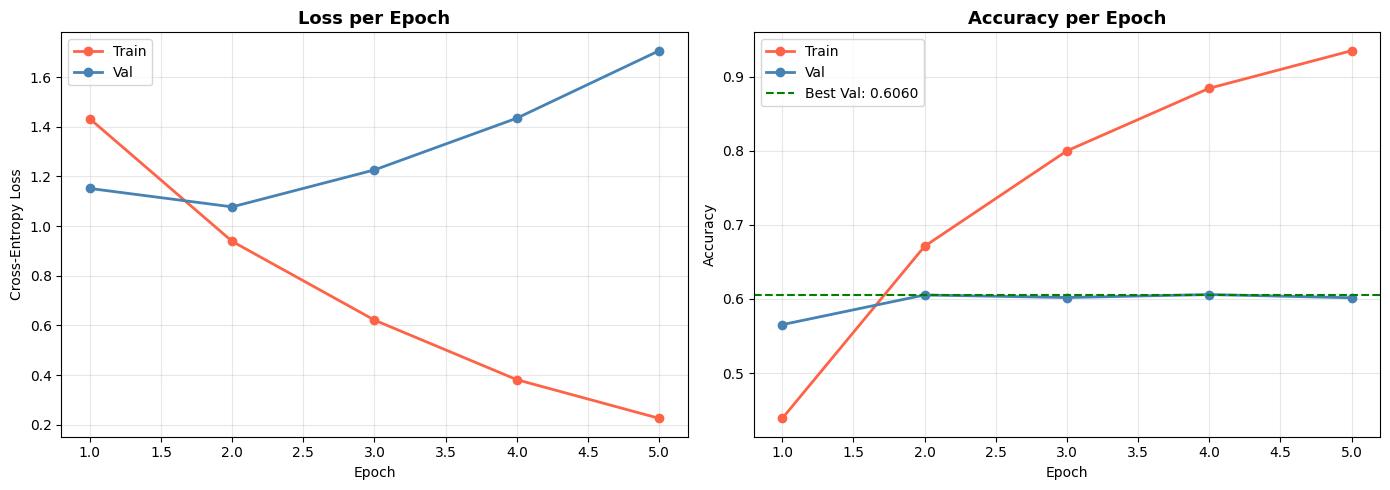

Best Validation Accuracy : 0.6060


In [ ]:
hist = cnn_history.history
epochs_ran = range(1, len(hist['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Loss
axes[0].plot(epochs_ran, hist['loss'],     marker='o', color='tomato',    linewidth=2, label='Train')
axes[0].plot(epochs_ran, hist['val_loss'], marker='o', color='steelblue', linewidth=2, label='Val')
axes[0].set_title('Loss per Epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Accuracy
axes[1].plot(epochs_ran, hist['accuracy'],     marker='o', color='tomato',    linewidth=2, label='Train')
axes[1].plot(epochs_ran, hist['val_accuracy'], marker='o', color='steelblue', linewidth=2, label='Val')
best_val_acc = max(hist['val_accuracy'])
axes[1].axhline(best_val_acc, color='green', linestyle='--', linewidth=1.5,
                label=f'Best Val: {best_val_acc:.4f}')
axes[1].set_title('Accuracy per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best Validation Accuracy : {best_val_acc:.4f}")

##  10. Final Evaluation on Test Set

In [ ]:
test_loss, test_acc = cnn_model.evaluate(X_test_enc, y_test_enc, verbose=0)
print(f" Test Accuracy : {test_acc:.4f}")
print(f"   Test Loss     : {test_loss:.4f}")

 Test Accuracy : 0.6318
   Test Loss     : 1.0457


In [ ]:
y_pred_probs = cnn_model.predict(X_test_enc, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.argmax(y_test_enc,   axis=1)
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support
       anger       0.62      0.53      0.57       414
        fear       0.73      0.68      0.70       518
         joy       0.69      0.67      0.68      1056
     neutral       0.78      0.68      0.73       188
     sadness       0.55      0.60      0.58       635
    surprise       0.49      0.58      0.53       388
    accuracy                           0.63      3199
   macro avg       0.64      0.63      0.63      3199
weighted avg       0.64      0.63      0.63      3199


##  11. Confusion Matrix

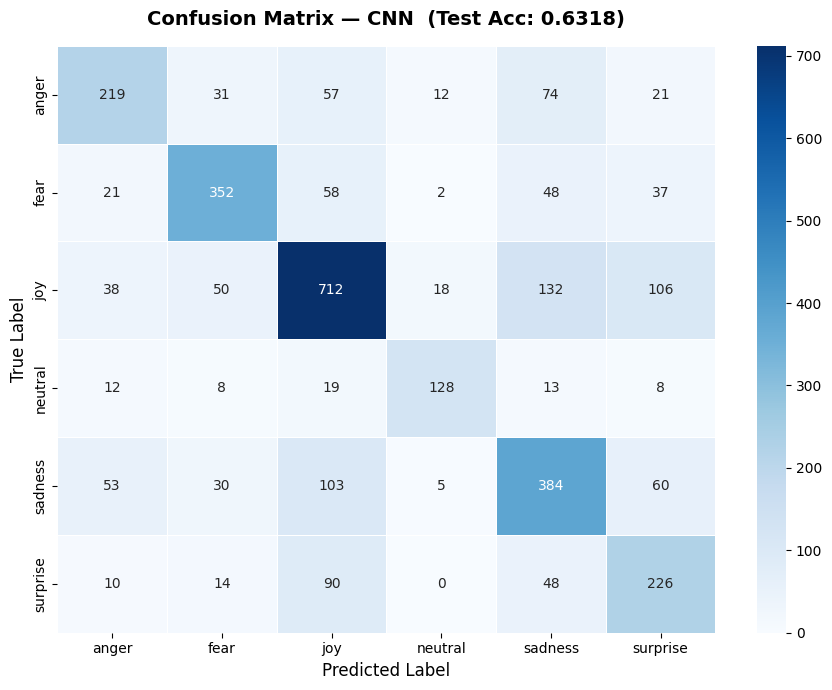

In [ ]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax, linewidths=0.5
)
ax.set_title(
    f'Confusion Matrix — CNN  (Test Acc: {test_acc:.4f})',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

##  12. Save Results Summary

In [ ]:
import json
summary = {
    'model'         : 'CNN (Conv1D)',
    'num_classes'   : NUM_CLASSES,
    'classes'       : le.classes_.tolist(),
    'vocab_size'    : MAX_WORDS,
    'max_seq_len'   : MAX_LEN,
    'best_val_acc'  : round(best_val_acc, 4),
    'test_acc'      : round(float(test_acc), 4),
    'test_loss'     : round(float(test_loss), 4),
    'epochs_trained': len(hist['loss']),
    'train_samples' : len(X_train),
    'val_samples'   : len(X_val),
    'test_samples'  : len(X_test),
}
with open('cnn_results.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("Results saved to cnn_results.json")
print(json.dumps(summary, indent=2))

Results saved to cnn_results.json
{
  "model": "CNN (Conv1D)",
  "num_classes": 6,
  "classes": [
    "anger",
    "fear",
    "joy",
    "neutral",
    "sadness",
    "surprise"
  ],
  "vocab_size": 10000,
  "max_seq_len": 100,
  "best_val_acc": 0.606,
  "test_acc": 0.6318,
  "test_loss": 1.0457,
  "epochs_trained": 5,
  "train_samples": 14926,
  "val_samples": 3198,
  "test_samples": 3199
}


In [ ]:
from google.colab import files
files.download('cnn_results.json')
files.download('cnn_best.h5')
files.download('cnn_training_curves.png')
files.download('cnn_confusion_matrix.png')
#

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>